# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pr120107/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import os
import subprocess
import sys

REPO_URL = "https://github.com/pr120107/flyrank-ml-internship.git"
REPO_DIR = "/content/flyrank-ml-internship"

# Clone the repo if it is not already available
if not os.path.isdir(REPO_DIR):
    subprocess.run(
        ["git", "clone", REPO_URL, REPO_DIR],
        check=True
    )

# Move into the repository
os.chdir(REPO_DIR)

print("Working directory:", os.getcwd())
print("Repo contents:", os.listdir()[:10])

Working directory: /content/flyrank-ml-internship
Repo contents: ['SETUP.md', 'README.md', 'work', 'LICENSE', 'notebooks', 'submission', 'outputs', 'data', 'requirements.txt', 'skills']


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [4]:
# ============================================================
# Section 1 — Ranked actions + reason codes
# ============================================================

import os
import numpy as np
import pandas as pd

DATA_PATH = "data/raw/content_refresh_anonymized.csv"

if not os.path.exists(DATA_PATH):
    REPO_DIR = "/content/flyrank-ml-internship"
    if os.path.isdir(REPO_DIR):
        os.chdir(REPO_DIR)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

engagement_score = (
    df["engagement_rate"]
    .clip(lower=0, upper=100)
    .fillna(0)
    / 100
)

visibility_score = (
    np.log1p(df["impressions_90d"].clip(lower=0))
    / np.log1p(df["impressions_90d"].clip(lower=0).max())
)

df["priority_score"] = 100 * (
    0.60 * engagement_score +
    0.40 * visibility_score
)

df["reason_code"] = np.select(
    [
        (
            (df["engagement_rate"] >= 60) &
            (df["impressions_90d"] >= 500)
        ),

        (
            (df["engagement_rate"] >= 60) &
            (df["impressions_90d"] < 500)
        ),

        (
            (df["engagement_rate"] < 1) &
            (df["impressions_90d"] >= 500)
        ),

        (
            (df["days_since_last_update"] >= 180) &
            (df["impressions_90d"] >= 100)
        )
    ],
    [
        "high_engagement_visible",
        "high_engagement_low_volume",
        "low_engagement_visible",
        "stale_content"
    ],
    default="monitor"
)

action_map = {
    "high_engagement_visible": "review_archetype",
    "high_engagement_low_volume": "review_context",
    "low_engagement_visible": "review_value_and_engagement",
    "stale_content": "review_refresh_need",
    "monitor": "monitor"
}

df["action"] = df["reason_code"].map(action_map)

df = (
    df.sort_values(
        ["priority_score", "impressions_90d"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

df["rank"] = np.arange(1, len(df) + 1)

queue_columns = [
    "rank",
    "content_id",
    "priority_score",
    "reason_code",
    "action",
    "content_type",
    "main_intent",
    "engagement_rate",
    "impressions_90d",
    "days_since_last_update",
    "content_age_days"
]

queue = df[queue_columns].copy()

print("\nTop 20 action queue:")
display(queue.head(20))

print("\nReason-code counts:")
display(
    queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="pages")
)

print("\nAction counts:")
display(
    queue["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="pages")
)

Dataset shape: (30000, 44)

Top 20 action queue:


,rank,content_id,priority_score,reason_code,action,content_type,main_intent,engagement_rate,impressions_90d,days_since_last_update,content_age_days
0,1,content_139f09ffd77b,86.627493,high_engagement_visible,review_archetype,keyword article,informational,100.0,6364,15,133
1,2,content_d016173fedb8,84.362889,high_engagement_visible,review_archetype,keyword article,informational,100.0,3021,13,228
2,3,content_8aa0d6cfc237,84.207055,high_engagement_visible,review_archetype,keyword article,informational,100.0,2870,20,97
3,4,content_e9785b5bd320,82.832946,high_engagement_visible,review_archetype,keyword article,commercial,100.0,1826,104,313
4,5,content_4c8b6a410f88,82.677618,high_engagement_visible,review_archetype,keyword article,transactional,100.0,1735,20,92
5,6,content_5f81f901e2e6,82.344826,high_engagement_visible,review_archetype,keyword article,transactional,100.0,1555,104,330
6,7,content_64b2508ad098,82.297569,high_engagement_visible,review_archetype,keyword article,informational,100.0,1531,20,557
7,8,content_ce611830d125,82.045283,high_engagement_visible,review_archetype,keyword article,informational,100.0,1409,104,144
8,9,content_e7b4e9967ffa,81.979900,high_engagement_visible,review_archetype,keyword article,informational,100.0,1379,7,421
9,10,content_7a08dc784d80,81.872273,high_engagement_visible,review_archetype,keyword article,commercial,100.0,1331,7,347



Reason-code counts:


,reason_code,pages
0,monitor,20080
1,low_engagement_visible,9787
2,high_engagement_low_volume,88
3,stale_content,24
4,high_engagement_visible,21



Action counts:


,action,pages
0,monitor,20080
1,review_value_and_engagement,9787
2,review_context,88
3,review_refresh_need,24
4,review_archetype,21


## Interpretation

The queue is a **human-review prioritization tool**, not an automated content decision system.

The priority score combines observed engagement and 90-day search visibility. Engagement receives 60% of the score and log-scaled impressions receive 40%, reducing the influence of very large traffic counts.

The first run produced 30,000 ranked pages. The strongest high-priority group contained 21 pages with both high engagement and meaningful visibility. A larger group of pages showed lower engagement despite having visibility, so those pages are treated as a broader review population rather than automatically requiring an intervention.

Reason codes translate observed signals into review types:

* `high_engagement_visible` -> examine what characteristics of these visible, highly engaged pages may be worth learning from.
* `high_engagement_low_volume` -> investigate whether the page has a useful experience or content pattern despite limited visibility.
* `low_engagement_visible` -> review the page's value proposition and engagement pattern, while avoiding the assumption that poor engagement has a single cause.
* `stale_content` -> check whether the information is still current and whether a refresh is justified.
* `monitor` -> no strong action signal from this rule set.

The queue ranks pages for **human review**. It does not establish that a page needs a rewrite, refresh, deletion, or other specific intervention.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [6]:
summary = {
    "total_pages": len(df),
    "queued_pages": int(
        df["reason_code"].isin([
            "high_engagement_visible",
            "high_engagement_low_volume",
            "low_engagement_visible",
            "stale_content"
        ]).sum()
    ),
    "high_engagement_visible": int(
        (df["reason_code"] == "high_engagement_visible").sum()
    ),
    "high_engagement_low_volume": int(
        (df["reason_code"] == "high_engagement_low_volume").sum()
    ),
    "low_engagement_visible": int(
        (df["reason_code"] == "low_engagement_visible").sum()
    ),
    "stale_content": int(
        (df["reason_code"] == "stale_content").sum()
    )
}

summary_table = pd.DataFrame({
    "measure": [
        "Total pages",
        "Pages with an action signal",
        "High engagement + visible",
        "High engagement + low volume",
        "Low engagement + visible",
        "Stale + measurable visibility"
    ],
    "value": [
        summary["total_pages"],
        summary["queued_pages"],
        summary["high_engagement_visible"],
        summary["high_engagement_low_volume"],
        summary["low_engagement_visible"],
        summary["stale_content"]
    ]
})

display(summary_table)

,measure,value
0,Total pages,30000
1,Pages with an action signal,9920
2,High engagement + visible,21
3,High engagement + low volume,88
4,Low engagement + visible,9787
5,Stale + measurable visibility,24


## Intended use

The playbook is intended for **content strategists, SEO teams, or analysts** who need to decide which pages deserve human investigation first.

The output can support questions such as:

* Which pages should a reviewer inspect first?
* Which high-performing pages may provide useful archetype examples?
* Which visible pages show weaker engagement and deserve investigation?
* Which older pages may need a freshness check?

The output is **decision support**, not an automatic content editor.

## Limits

The signals are observational. A relationship between a page characteristic and performance does not prove that changing that characteristic will cause performance to improve.

A high engagement rate does not automatically mean that the page should be copied, expanded, or treated as a best practice. Likewise, a stale page is not automatically a page that should be refreshed.

The queue also depends on the available measurement data. Pages with limited visibility or incomplete measurements can receive less informative signals.

Finally, validation across held-out clients was more conservative than a random page split. The resulting recommendations should therefore be treated as directional evidence and reviewed before being generalized to new clients.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [8]:
# ============================================================
# Section 3 — Human review + no-go list
# ============================================================

review_rules = pd.DataFrame({
    "reason_code": [
        "high_engagement_visible",
        "high_engagement_low_volume",
        "low_engagement_visible",
        "stale_content"
    ],
    "human_review_focus": [
        "Identify useful page/archetype characteristics; verify context before reuse.",
        "Check whether limited visibility is caused by demand, targeting, or another factor.",
        "Investigate page value, intent alignment, and engagement context before changing content.",
        "Check factual freshness and determine whether a refresh is actually justified."
    ]
})

display(review_rules)

,reason_code,human_review_focus
0,high_engagement_visible,Identify useful page/archetype characteristics...
1,high_engagement_low_volume,Check whether limited visibility is caused by ...
2,low_engagement_visible,"Investigate page value, intent alignment, and ..."
3,stale_content,Check factual freshness and determine whether ...


## Human review rules

The action queue is intended to prioritize investigation, while the final content decision remains with a human reviewer.

For each queued page, the reviewer should:

1. Verify that the page's current search intent is still relevant.
2. Check whether the observed engagement and visibility signals are consistent with the page's current role.
3. Inspect the page content and business context before recommending an action.
4. Check whether the page overlaps with another page or serves a distinct intent.
5. Decide whether the appropriate outcome is refresh, maintain, investigate further, or no action.
6. Record the reason for the final decision so outcomes can later be used for monitoring and model validation.

## What should NOT be automated

The score should **not** automatically:

- rewrite or publish content;
- delete pages;
- redirect URLs;
- change search intent;
- change titles or metadata;
- merge or split pages;
- declare a page successful or unsuccessful;
- treat high engagement as proof that a content pattern should be copied;
- treat low engagement as proof that a page should be removed;
- treat staleness as proof that a page needs a refresh.

These decisions require page-level context that is not represented by the action score alone.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [9]:
monitoring_features = [
    "engagement_rate",
    "impressions_90d",
    "days_since_last_update",
    "content_age_days"
]

monitoring_summary = pd.DataFrame({
    "feature": monitoring_features,
    "missing_values": [
        int(df[col].isna().sum()) for col in monitoring_features
    ],
    "missing_rate_pct": [
        round(df[col].isna().mean() * 100, 2)
        for col in monitoring_features
    ]
})

display(monitoring_summary)

reason_distribution = (
    df["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="pages")
)

reason_distribution["share_pct"] = (
    reason_distribution["pages"] / len(df) * 100
).round(2)

print("Current reason-code distribution:")
display(reason_distribution)

,feature,missing_values,missing_rate_pct
0,engagement_rate,0,0.0
1,impressions_90d,0,0.0
2,days_since_last_update,0,0.0
3,content_age_days,0,0.0


Current reason-code distribution:


,reason_code,pages,share_pct
0,monitor,20080,66.93
1,low_engagement_visible,9787,32.62
2,high_engagement_low_volume,88,0.29
3,stale_content,24,0.08
4,high_engagement_visible,21,0.07


The action playbook should be monitored after deployment because the underlying content, traffic, search behavior, and measurement distributions can change over time.

## Monitoring triggers

Review the playbook when any of the following occurs:

- The distribution of key input features changes substantially.
- Missingness patterns change, especially for features used by the queue.
- The proportion of pages receiving each reason code changes substantially.
- The composition of the top-ranked queue changes unexpectedly.
- New content types, intents, or client groups appear that were not represented during validation.
- Human reviewers consistently disagree with the reason code or suggested review focus.

## Retrain / recalibration triggers

Retraining or recalibration should be considered when:

- newly labeled outcomes show a sustained decline in ranking quality;
- grouped-by-client validation performance deteriorates materially;
- feature distributions or missingness patterns show persistent drift;
- the relationship between the observed signals and the target outcome changes;
- the content population changes enough that the original validation data is no longer representative.

A retrain should not be triggered by a single unusual page or a short-term fluctuation. Evidence should be accumulated over a meaningful evaluation period.

## Monitoring principle

The system should monitor **data quality, ranking behavior, and eventual outcomes separately**. A change in the queue alone does not prove that model performance has degraded.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Repository root: /content/flyrank-ml-internship
Using existing dataframe: (30000, 48)


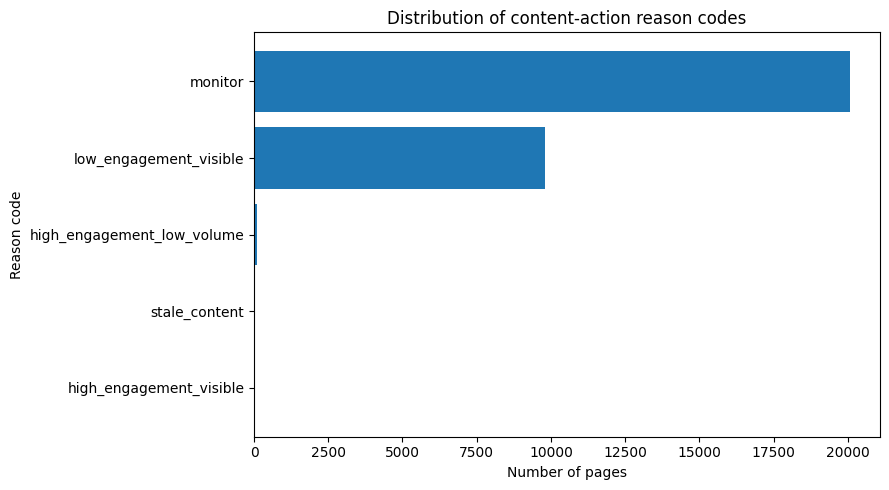


Exported files:
- Ranked queue: /content/flyrank-ml-internship/work/outputs/w07_action_queue.csv
- Reason summary: /content/flyrank-ml-internship/work/outputs/w07_reason_code_summary.csv
- Paper figure: /content/flyrank-ml-internship/work/figures/w07_reason_code_distribution.png

Queue shape: (30000, 11)

Top 10 exported queue rows:


,rank,content_id,priority_score,reason_code,action,content_type,main_intent,engagement_rate,impressions_90d,days_since_last_update,content_age_days
0,1,content_139f09ffd77b,86.627493,high_engagement_visible,review_archetype,keyword article,informational,100.0,6364,15,133
1,2,content_d016173fedb8,84.362889,high_engagement_visible,review_archetype,keyword article,informational,100.0,3021,13,228
2,3,content_8aa0d6cfc237,84.207055,high_engagement_visible,review_archetype,keyword article,informational,100.0,2870,20,97
3,4,content_e9785b5bd320,82.832946,high_engagement_visible,review_archetype,keyword article,commercial,100.0,1826,104,313
4,5,content_4c8b6a410f88,82.677618,high_engagement_visible,review_archetype,keyword article,transactional,100.0,1735,20,92
5,6,content_5f81f901e2e6,82.344826,high_engagement_visible,review_archetype,keyword article,transactional,100.0,1555,104,330
6,7,content_64b2508ad098,82.297569,high_engagement_visible,review_archetype,keyword article,informational,100.0,1531,20,557
7,8,content_ce611830d125,82.045283,high_engagement_visible,review_archetype,keyword article,informational,100.0,1409,104,144
8,9,content_e7b4e9967ffa,81.979900,high_engagement_visible,review_archetype,keyword article,informational,100.0,1379,7,421
9,10,content_7a08dc784d80,81.872273,high_engagement_visible,review_archetype,keyword article,commercial,100.0,1331,7,347



Reason-code summary:


,reason_code,pages,share_pct,action
0,monitor,20080,66.93,monitor
1,low_engagement_visible,9787,32.62,review_value_and_engagement
2,high_engagement_low_volume,88,0.29,review_context
3,stale_content,24,0.08,review_refresh_need
4,high_engagement_visible,21,0.07,review_archetype


In [11]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Locate repository root
current_path = Path.cwd().resolve()
repo_root = None

for path in [current_path, *current_path.parents]:
    if (path / "data" / "raw" / "content_refresh_anonymized.csv").exists():
        repo_root = path
        break

if repo_root is None:
    raise FileNotFoundError(
        "Could not locate the FlyRank repository. "
        f"Current directory: {current_path}"
    )

print("Repository root:", repo_root)

# 2. Create output directories
outputs_dir = repo_root / "work" / "outputs"
figures_dir = repo_root / "work" / "figures"

outputs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# 3. Make sure the current dataframe exists
if "df" not in globals():
    data_path = repo_root / "data" / "raw" / "content_refresh_anonymized.csv"
    df = pd.read_csv(data_path)
    print("Loaded dataset:", df.shape)
else:
    print("Using existing dataframe:", df.shape)

# 4. Rebuild action mapping
action_map = {
    "high_engagement_visible": "review_archetype",
    "high_engagement_low_volume": "review_context",
    "low_engagement_visible": "review_value_and_engagement",
    "stale_content": "review_refresh_need",
    "monitor": "monitor"
}

# 5. Rebuild priority score and reason codes if necessary
if "priority_score" not in df.columns:

    engagement_score = (
        df["engagement_rate"]
        .clip(lower=0, upper=100)
        / 100
    )

    visibility_score = (
        np.log1p(df["impressions_90d"])
        / np.log1p(df["impressions_90d"].max())
    )

    df["priority_score"] = (
        100 * (
            0.60 * engagement_score +
            0.40 * visibility_score
        )
    )

if "reason_code" not in df.columns:

    df["reason_code"] = np.select(
        [
            (
                (df["engagement_rate"] >= 60) &
                (df["impressions_90d"] >= 500)
            ),
            (
                (df["engagement_rate"] >= 60) &
                (df["impressions_90d"] < 500)
            ),
            (
                (df["engagement_rate"] < 1) &
                (df["impressions_90d"] >= 500)
            ),
            (
                (df["days_since_last_update"] >= 180) &
                (df["impressions_90d"] >= 100)
            )
        ],
        [
            "high_engagement_visible",
            "high_engagement_low_volume",
            "low_engagement_visible",
            "stale_content"
        ],
        default="monitor"
    )

df["action"] = df["reason_code"].map(action_map)

# 6. Create final ranked action queue
queue_columns = [
    "content_id",
    "priority_score",
    "reason_code",
    "action",
    "content_type",
    "main_intent",
    "engagement_rate",
    "impressions_90d",
    "days_since_last_update",
    "content_age_days"
]

action_queue = (
    df[queue_columns]
    .sort_values(
        ["priority_score", "impressions_90d"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

action_queue.insert(
    0,
    "rank",
    np.arange(1, len(action_queue) + 1)
)

# 7. Export ranked queue
queue_path = outputs_dir / "w07_action_queue.csv"

action_queue.to_csv(
    queue_path,
    index=False
)

# 8. Export reason-code summary
reason_summary = (
    df["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="pages")
)

reason_summary["share_pct"] = (
    reason_summary["pages"] / len(df) * 100
).round(2)

reason_summary["action"] = (
    reason_summary["reason_code"]
    .map(action_map)
)

reason_summary_path = (
    outputs_dir / "w07_reason_code_summary.csv"
)

reason_summary.to_csv(
    reason_summary_path,
    index=False
)

# 9. Create reusable paper figure
plot_data = reason_summary.sort_values(
    "pages",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["reason_code"],
    plot_data["pages"]
)

plt.xlabel("Number of pages")
plt.ylabel("Reason code")
plt.title("Distribution of content-action reason codes")

plt.tight_layout()

figure_path = (
    figures_dir /
    "w07_reason_code_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 10. Verify exports
print("\nExported files:")
print(f"- Ranked queue: {queue_path}")
print(f"- Reason summary: {reason_summary_path}")
print(f"- Paper figure: {figure_path}")

print("\nQueue shape:", action_queue.shape)

print("\nTop 10 exported queue rows:")
display(action_queue.head(10))

print("\nReason-code summary:")
display(reason_summary)

The final action queue is exported as a reusable CSV for downstream review.

The export contains the ranking, priority score, reason code, recommended review action, and key page-level signals used to interpret the queue.

A separate reason-code summary is exported for reporting, and a reusable figure is saved under `work/figures/`.

The queue is an analytical artifact for human review. It is not a production publishing or content-editing command.

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd

# 1. Required files exist
required_files = [
    queue_path,
    reason_summary_path,
    figure_path
]

file_checks = {
    str(path): path.exists()
    for path in required_files
}

# 2. Queue structure checks
queue_check = (
    len(action_queue) == len(df)
)

rank_check = (
    action_queue["rank"].is_unique
    and action_queue["rank"].min() == 1
    and action_queue["rank"].max() == len(action_queue)
)

score_check = (
    action_queue["priority_score"].notna().all()
    and np.isfinite(action_queue["priority_score"]).all()
    and action_queue["priority_score"].between(0, 100).all()
)

reason_check = (
    action_queue["reason_code"].isin(action_map.keys()).all()
)

action_check = (
    action_queue["action"].notna().all()
)

# 3. Leakage checks
leakage_columns = {
    "trend_direction",
    "trend_pct"
}

exported_columns = set(action_queue.columns)

leakage_check = exported_columns.isdisjoint(leakage_columns)

# 4. Print results
checks = {
    "Required files exist": all(file_checks.values()),
    "Queue contains all dataset rows": queue_check,
    "Ranks are unique and sequential": rank_check,
    "Priority scores are valid": score_check,
    "Reason codes are valid": reason_check,
    "Actions are populated": action_check,
    "Leakage columns excluded": leakage_check
}

print("Week 7 self-check")
print("=" * 50)

for check_name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {check_name}")

# 5. Final assertion
assert all(checks.values()), (
    "One or more Week 7 self-checks failed. "
    "Review the failed checks above."
)

print("\nAll Week 7 self-checks passed.")
print("The action playbook is ready for review.")

Week 7 self-check
[PASS] Required files exist
[PASS] Queue contains all dataset rows
[PASS] Ranks are unique and sequential
[PASS] Priority scores are valid
[PASS] Reason codes are valid
[PASS] Actions are populated
[PASS] Leakage columns excluded

All Week 7 self-checks passed.
The action playbook is ready for review.


In [16]:
import subprocess

paths_to_check = [
    "work/outputs/w07_action_queue.csv",
    "work/outputs/w07_reason_code_summary.csv",
    "work/outputs/w07_metrics.json",
    "work/figures/w07_reason_code_distribution.png"
]

for path in paths_to_check:
    result = subprocess.run(
        ["git", "check-ignore", "-v", path],
        cwd=repo_root,
        capture_output=True,
        text=True
    )

    if result.stdout.strip():
        print(f"IGNORED: {path}")
        print(f"  {result.stdout.strip()}")
    else:
        print(f"NOT IGNORED: {path}")

IGNORED: work/outputs/w07_action_queue.csv
  .gitignore:28:work/**/*.csv	work/outputs/w07_action_queue.csv
IGNORED: work/outputs/w07_reason_code_summary.csv
  .gitignore:28:work/**/*.csv	work/outputs/w07_reason_code_summary.csv
NOT IGNORED: work/outputs/w07_metrics.json
NOT IGNORED: work/figures/w07_reason_code_distribution.png


In [15]:
import subprocess

result = subprocess.run(
    ["git", "status", "--short"],
    cwd=repo_root,
    capture_output=True,
    text=True
)

print(result.stdout)

?? work/figures/



## 6. Self-check

The Week 7 playbook should satisfy the following checks:

- The ranked queue contains all dataset rows.
- Rankings are unique and sequential.
- Priority scores are finite and within the intended 0-100 range.
- Every page has a valid reason code and action.
- The queue does not use `trend_direction` or `trend_pct`, which are leakage-prone target information.
- Required output files exist.
- The exported figure is available under `work/figures/`.
- The queue is intended for human review rather than automated content changes.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.